# Gradient boosting: features, tuning, and implementation

We forecast all **336 hours at one fixed origin**, using only earlier observations.
This notebook follows the experiments in the order they informed our decisions:
calendar representation → recent temperature → weather → tuning → training history.
Both successful and unsuccessful comparisons are retained. The final section shows
how the findings are applied in `src/` and the shared workflow.

## 1. Setup and evaluation

The delivered notebook contains executed tables and plots. One compact results
file holds the completed validation scores, exact candidate settings, and horizon
summaries; it contains no copied datasets or hourly prediction files. Leave
`RUN_STAGES = []` to inspect those results, or add stage names to refit through
`src.workflow.tune_models`. Earlier stages contain 450 fits; the bounded
regularization follow-up, history recheck, and updated development confirmation
add 150. Direct-context fits take longer. Earlier recipes explicitly retain their
50-sample leaves / L2=1 settings so changing production defaults cannot alter a replay.

Every fit uses pre-origin history, and every candidate predicts the complete grid.
We select by **equal-window mean MAE in °F** across the same five development windows;
RMSE and window variation are supporting diagnostics. Missing actuals are excluded
from scoring, while missing lag/weather inputs remain NaN. Internal random-split
early stopping is disabled. No audit or submission targets are scored here.

In [1]:
from pathlib import Path
import contextlib
import io
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from threadpoolctl import threadpool_limits

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'src').is_dir():
    raise FileNotFoundError('Open from the repository root or notebooks folder.')
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import FORECAST_START, RAW_PATH, VALIDATION_WINDOWS
from src.data_pipeline import WEATHER_COLUMNS, clean_hourly_data
from src.features import CALENDAR_FEATURES
from src.gradient_boosting_features import TEMPERATURE_CONTEXT, WEATHER_GROUPS, make_direct_training_data
from src.gradient_boosting_model import DEFAULT_GRADIENT_BOOSTING_PARAMS, resolve_config
from src.workflow import expand_candidates, file_sha256, load_experiment, tune_models

RUN_STAGES = []  # Stage names are printed below; add names to refit through src.
CACHE_PATH = PROJECT_ROOT / 'notebooks/gradient_boosting_results.json'
results = json.loads(CACHE_PATH.read_text())
assert not set(RUN_STAGES).difference(results['stages']), 'Unknown experiment stage.'
if file_sha256(RAW_PATH) != results['raw_input_sha256']:
    if set(RUN_STAGES) != set(results['stages']):
        raise ValueError('Raw data changed: rerun every stage before comparing with saved results.')

pd.set_option('display.max_columns', 12)
pd.set_option('display.width', 140)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .2})
print('Recorded environment:', results['environment'])
print('Stage fit counts:', {name: stage['validation_fits'] for name, stage in results['stages'].items()})

Recorded environment: {'python': '3.12.14', 'numpy': '2.3.5', 'pandas': '2.2.3', 'scikit-learn': '1.8.0'}
Stage fit counts: {'calendar': 75, 'features': 65, 'combined': 5, 'parameters': 130, 'history': 75, 'density': 10, 'development': 90, 'regularization': 45, 'regularization_history': 15, 'development_regularized': 90}


In [2]:
# Small notebook helpers; model fitting and scoring remain in src.
def experiment(feature_sets, lookbacks=(None,), grid=None, baselines=True):
    models = [{'name': name} for name in ['month_hour', 'repeat_last_day']] if baselines else []
    models.append({'name': 'gradient_boosting', 'feature_sets': feature_sets,
                   'param_grid': {'min_samples_leaf': [50], 'l2_regularization': [1.], **(grid or {})}})
    return {'lookbacks': list(lookbacks), 'models': models}


def run_or_load(name, recipe):
    saved = results['stages'][name]
    assert recipe == saved['experiment'], 'Recipe changed: use a new results cache for a new experiment.'
    if name in RUN_STAGES:
        print(f'Refitting {name}: {saved["validation_fits"]} validation fits...', flush=True)
        with threadpool_limits(limits=2), contextlib.redirect_stdout(io.StringIO()):
            metrics, predictions, summary, _ = tune_models(hourly, recipe, include_weather=True)
        observed = predictions.dropna(subset=['y']).copy()
        observed['error'] = (observed.yhat - observed.y).abs()
        daily = observed.groupby(['candidate_id', 'lookback', 'window', 'forecast_day']).error.mean()
        daily = daily.groupby(['candidate_id', 'lookback', 'forecast_day']).mean().reset_index(name='mae')
        candidates, _ = expand_candidates(recipe)
        saved.update(summary=json.loads(summary.to_json(orient='records')),
                     metrics=json.loads(metrics.to_json(orient='records')),
                     daily_mae=json.loads(daily.to_json(orient='records')),
                     candidates=candidates,
                     source_sha256={str(p.relative_to(PROJECT_ROOT)): file_sha256(p)
                                    for p in sorted((PROJECT_ROOT / 'src').glob('*.py'))},
                     completed_utc=pd.Timestamp.now(tz='UTC').isoformat(),
                     result_origin='refit with current src')
        results['raw_input_sha256'] = file_sha256(RAW_PATH)
        CACHE_PATH.write_text(json.dumps(results, indent=2, allow_nan=False) + '\n')
    table = pd.DataFrame(saved['summary'])
    table['candidate'] = table.candidate_id.map(lambda key: feature_label(saved['candidates'][key]))
    return table, saved


def feature_label(config):
    if config['model'] != 'gradient_boosting':
        return {'month_hour': 'Month/hour baseline', 'repeat_last_day': 'Repeat last day'}[config['model']]
    columns = config['feature_columns']
    if 'forecast_hour' in columns:
        groups = [name.replace('_', ' ') for name, features in WEATHER_GROUPS.items()
                  if set(features).issubset(columns)]
        return 'Direct: ' + (' + '.join(groups) if groups else 'temperature context')
    if 'lag_1' in columns:
        return 'Recursive: lags' + (' + mean' if 'rolling_mean_24' in columns else '')
    return {3: 'Raw calendar', 4: 'Cyclic calendar', 7: 'Combined calendar'}[len(columns)]

We clean the checked-in reports in memory with the shared pipeline. The submission
begins at September 17, 2026 **04:00 UTC** (midnight Eastern); its 04:00 label
represents the usual **04:51 UTC / 00:51 Eastern** report. Shared calendar features
use UTC. The coverage table also records how many actuals each validation score uses.

In [3]:
raw = pd.read_csv(RAW_PATH, na_values=['M'], low_memory=False)
hourly, cleaning = clean_hourly_data(raw, pd.Timestamp('2015-01-01', tz='UTC'),
                                   FORECAST_START, include_weather=True)
print(f'{len(hourly):,} hourly rows; {hourly.y.notna().sum():,} observed targets; '
      f'{hourly.y.isna().sum()} missing targets.')
display(pd.DataFrame([{'window': w.name, 'origin_utc': w.start, 'forecast_hours': 336,
                       'observed_targets': hourly.loc[hourly.ds.isin(w.timestamps()), 'y'].notna().sum()}
                      for w in VALIDATION_WINDOWS]))

,window,origin_utc,forecast_hours,observed_targets
0,september_2022,2022-09-17 04:00:00+00:00,336,336
1,september_2023,2023-09-17 04:00:00+00:00,336,336
2,september_2024,2024-09-17 04:00:00+00:00,336,336
3,september_2025,2025-09-17 04:00:00+00:00,336,334
4,recent_2026,2026-08-20 04:00:00+00:00,336,336


102,652 hourly rows; 102,495 observed targets; 157 missing targets.


## 2. Calendar features and baseline comparison

First hold estimator settings fixed: learning rate 0.05, 150 iterations, **15 leaves**,
minimum leaf size 50, L2 penalty 1, squared-error loss, seed 520. Compare raw calendar
numbers, cyclic encodings, and their combination, using all available / five / three
years of training history. The month/hour average and repeat-last-day baselines
check whether flexibility adds value beyond simple seasonal and persistence forecasts.

In [4]:
calendar_sets = [['hour', 'month', 'dayofyear'],
                 ['hour_sin', 'hour_cos', 'year_sin', 'year_cos'], CALENDAR_FEATURES]
calendar, calendar_run = run_or_load('calendar', experiment(
    calendar_sets, (None, 5, 3), {'max_leaf_nodes': [15]}))
display(calendar.pivot(index='candidate', columns='lookback', values='mean_mae')
        .reindex(columns=['all', '5', '3']).round(3))

lookback,all,5,3
candidate,,,
Combined calendar,4.750,5.235,5.442
Cyclic calendar,4.774,5.239,5.434
Month/hour baseline,4.997,5.173,4.897
Raw calendar,4.808,5.268,5.335
Repeat last day,6.729,6.729,6.729


**Finding:** combined calendar with all history has MAE **4.750°F**, compared with
4.774°F for cyclic-only and 4.808°F for raw-only. The best month/hour baseline uses
three years (4.897°F); repeat-last-day scores 6.729°F. The differences between
calendar representations are small, but combined inputs and all history provide
the strongest starting reference. Carry them into the feature experiments.

## 3. Recent temperature: recursive lags and a direct reference

Add `lag_1` and `lag_24`, then `rolling_mean_24`, with estimator settings unchanged.
Training features use temperatures strictly before each target. At forecast time
we advance **one hour at a time**: earlier predictions replace observations in the
lags and rolling mean. At hour 25, even `lag_24` comes from a prediction. We never
feed validation actuals back into the forecast. Compare overall and daily MAE to
test whether any early benefit lasts across the full 14 days.

We also test a **pooled direct** reference: target-hour calendar features,
`forecast_hour`, and a fixed pre-origin snapshot (`temp_last`, `temp_mean_24`,
`temp_change_24`). Historical weekly origins simulate this same task, with all 336
training targets preceding the live validation origin. Context is held fixed across
the live horizon, avoiding recursive feedback. This changes the strategy, so it is
the reference for subsequent weather additions. Overlapping training horizons are
intentional; their rows are not independent observations.

,candidate,mean_mae,worst_mae,mean_rmse
0,Combined calendar,4.750,6.039,6.023
5,Direct: temperature context,4.983,6.033,6.234
10,Recursive: lags + mean,5.483,7.244,6.699
11,Recursive: lags,5.496,7.175,6.714


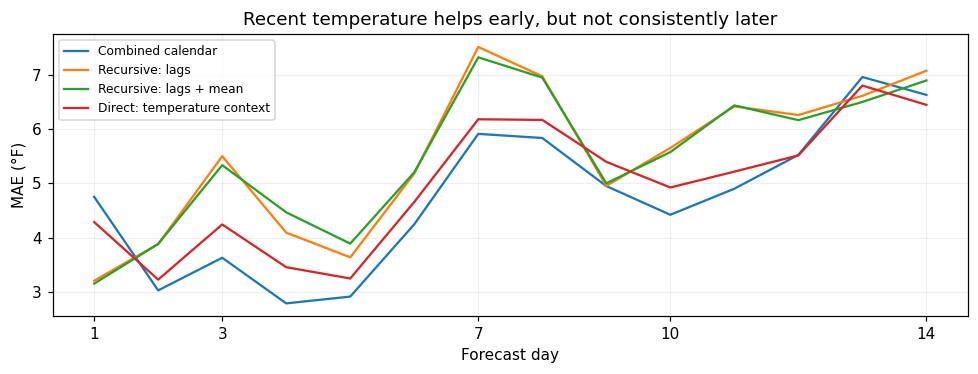

,candidate,mae
0,Combined calendar,4.752
14,Recursive: lags,3.206
28,Recursive: lags + mean,3.153
42,Direct: temperature context,4.287


In [5]:
direct_features = CALENDAR_FEATURES + ['forecast_hour'] + TEMPERATURE_CONTEXT
feature_sets = [CALENDAR_FEATURES, CALENDAR_FEATURES + ['lag_1', 'lag_24'],
                CALENDAR_FEATURES + ['lag_1', 'lag_24', 'rolling_mean_24'], direct_features]
feature_sets += [direct_features + group for group in WEATHER_GROUPS.values()]
features, feature_run = run_or_load('features', experiment(feature_sets, grid={'max_leaf_nodes': [15]}))
temperature_labels = ['Combined calendar', 'Recursive: lags', 'Recursive: lags + mean',
                      'Direct: temperature context']
display(features.loc[features.candidate.isin(temperature_labels),
                     ['candidate', 'mean_mae', 'worst_mae', 'mean_rmse']].round(3))
daily = pd.DataFrame(feature_run['daily_mae'])
daily['candidate'] = daily.candidate_id.map(lambda key: feature_label(feature_run['candidates'][key]))
daily.pivot(index='forecast_day', columns='candidate', values='mae')[temperature_labels].plot(figsize=(9, 3.5))
plt.ylabel('MAE (°F)'); plt.xlabel('Forecast day'); plt.title('Recent temperature helps early, but not consistently later')
plt.xticks([1, 3, 7, 10, 14]); plt.legend(fontsize=8); plt.tight_layout(); plt.show()
display(daily.loc[(daily.forecast_day == 1) & daily.candidate.isin(temperature_labels),
                  ['candidate', 'mae']].round(3))

**Finding:** recursive lags plus mean improve day-one MAE to **3.153°F** versus
4.752°F for calendar, but worsen full-window MAE to **5.483°F**. Lags alone are
similar (5.496°F overall). The direct temperature reference scores **4.983°F**.
Recent conditions help the start of the forecast; they do not automatically improve
the two-week task. Keep calendar as the lead model and test weather against the
same direct temperature reference, rather than crediting a strategy change to weather.

## 4. Weather candidates: coverage, screening, and controlled additions

Screen only history **before the earliest validation origin**. Examine missingness
and Pearson associations with day-one/day-fourteen targets at simulated origins;
seasonality and redundant inputs can produce associations without useful forecast gains.
All seven plausible groups still receive a controlled validation comparison.

Add dew point, wind speed, humidity, pressure, cloud cover, wind components, and
precipitation separately to the direct reference. Wind components avoid averaging
directions across 0°/360°. Cloud cover is an ordinal coverage proxy from the report;
precipitation uses a total and a trace flag. Means require 18 of the previous 24
observations, while precipitation totals require all 24. Future weather is never an input.

In [6]:
training = hourly.loc[hourly.ds < VALIDATION_WINDOWS[0].start].reset_index(drop=True)
display(pd.DataFrame({'input': WEATHER_COLUMNS,
                       'missing_percent': [100 * training[c].isna().mean() for c in WEATHER_COLUMNS]}).round(2))
context_columns = TEMPERATURE_CONTEXT + [c for group in WEATHER_GROUPS.values() for c in group]
inputs, targets, _ = make_direct_training_data(training, ['forecast_hour'] + context_columns, 4)
correlations = pd.DataFrame({'context': context_columns})
for name, mask in [('day_1', inputs.forecast_hour <= 24), ('day_14', inputs.forecast_hour > 312)]:
    correlations['pearson_' + name] = [inputs.loc[mask, c].corr(pd.Series(targets, index=inputs.index).loc[mask])
                                      for c in context_columns]
display(correlations.round(3))

,input,missing_percent
0,dewpoint,0.14
1,wind_speed,0.29
2,wind_direction,7.33
3,humidity,0.21
4,pressure,0.13
5,cloud_cover,0.14
6,precip,0.13
7,precip_trace,0.13


,context,pearson_day_1,pearson_day_14
0,temp_last,0.864,0.634
1,temp_mean_24,0.844,0.670
2,temp_change_24,0.190,-0.032
3,dewpoint_last,0.831,0.597
4,dewpoint_mean_24,0.800,0.603
5,wind_speed_mean_24,-0.001,0.040
6,humidity_mean_24,0.300,0.141
7,pressure_last,-0.236,-0.159
8,pressure_change_24,-0.178,0.013
9,cloud_cover_mean_24,0.117,0.035


In [7]:
metrics = pd.DataFrame(feature_run['metrics'])
reference_id = features.loc[features.candidate == 'Direct: temperature context', 'candidate_id'].iloc[0]
reference = metrics.loc[metrics.candidate_id == reference_id].set_index('window').mae
weather = features.loc[features.candidate.str.startswith('Direct:') &
                       features.candidate.ne('Direct: temperature context'),
                       ['candidate_id', 'candidate', 'mean_mae']].copy()
weather['change_vs_direct'] = weather.mean_mae - reference.mean()
weather['windows_improved'] = [int((metrics.loc[metrics.candidate_id == key].set_index('window').mae < reference).sum())
                               for key in weather.candidate_id]
display(weather.drop(columns='candidate_id').round(3))

,candidate,mean_mae,change_vs_direct,windows_improved
1,Direct: wind direction,4.884,-0.099,4
2,Direct: dew point,4.895,-0.088,5
3,Direct: pressure,4.976,-0.008,2
4,Direct: humidity,4.983,-0.000,3
7,Direct: wind speed,5.029,0.045,2
8,Direct: cloud cover,5.209,0.226,1
9,Direct: precipitation,5.337,0.354,2


**Finding:** dew point improves the direct reference in **5/5 windows** (MAE 4.895°F),
and wind components improve **4/5** (4.884°F). Pressure/humidity provide little
overall benefit; speed alone, cloud, and precipitation worsen this setup. Temperature
and dew-point associations weaken at longer horizons. Missing wind direction is
more common than missing speed, supporting explicit vector/missing-value handling.
Carry dew point and wind components forward as limited challengers; neither yet beats calendar.

## 5. Combine the promising weather groups

After the separate additions, combine dew point and wind components with the same
direct temperature reference and fixed settings. This tests whether their gains
are complementary; combining individually useful features need not help.

In [8]:
combined_columns = direct_features + WEATHER_GROUPS['dew_point'] + WEATHER_GROUPS['wind_direction']
combined, _ = run_or_load('combined', experiment([combined_columns], grid={'max_leaf_nodes': [15]}, baselines=False))
display(pd.concat([features.loc[features.candidate.isin(['Combined calendar', 'Direct: dew point',
                                                        'Direct: wind direction'])], combined])
        [['candidate', 'mean_mae', 'worst_mae']].sort_values('mean_mae').round(3))

,candidate,mean_mae,worst_mae
0,Combined calendar,4.750,6.039
1,Direct: wind direction,4.884,6.027
2,Direct: dew point,4.895,6.006
0,Direct: dew point + wind direction,4.911,5.973


**Finding:** the combination scores **4.911°F**, worse than either separate
addition. Keep the two separate weather variants for tuning; do not expand the
feature search further for this PR. These results concern the tested origin-context
features, not weather data's usefulness in every possible forecasting design.

## 6. Tune the shortlist

For combined calendar, direct dew point, and direct wind components, compare
learning rates **0.05/0.1**, iterations **150/300**, and leaves **7/15** using all
history: eight combinations per feature set, plus the two baselines (130 fits).
Keep minimum leaf size 50, L2 penalty 1, loss, seed, and early-stopping policy fixed.
This controls complexity and the amount of boosting; it is a small staged search,
not an exhaustive search. Display every tested combination below.

In [9]:
shortlist = [CALENDAR_FEATURES, direct_features + WEATHER_GROUPS['dew_point'],
             direct_features + WEATHER_GROUPS['wind_direction']]
parameters, parameter_run = run_or_load('parameters', experiment(shortlist, grid={
    'learning_rate': [.05, .1], 'max_iter': [150, 300], 'max_leaf_nodes': [7, 15]}))
for key in ['learning_rate', 'max_iter', 'max_leaf_nodes']:
    parameters[key] = parameters.candidate_id.map(lambda name: parameter_run['candidates'][name]['params'].get(key))
display(parameters.loc[parameters.model == 'gradient_boosting',
                       ['candidate', 'learning_rate', 'max_iter', 'max_leaf_nodes', 'mean_mae', 'worst_mae']].round(3))

,candidate,learning_rate,max_iter,max_leaf_nodes,mean_mae,worst_mae
0,Combined calendar,0.05,150.0,7.0,4.734,5.854
1,Combined calendar,0.10,150.0,7.0,4.734,6.052
2,Combined calendar,0.05,300.0,7.0,4.735,5.988
3,Direct: wind direction,0.05,150.0,7.0,4.749,6.017
4,Direct: wind direction,0.10,300.0,15.0,4.750,5.903
5,Combined calendar,0.05,150.0,15.0,4.750,6.039
6,Combined calendar,0.10,300.0,7.0,4.786,6.219
7,Combined calendar,0.05,300.0,15.0,4.796,6.235
8,Combined calendar,0.10,150.0,15.0,4.812,6.261
9,Direct: wind direction,0.05,300.0,7.0,4.848,6.068


**Finding:** the best mean-MAE configuration in each feature set uses learning rate
**0.05**, **150 iterations**, and **7 leaves**. Calendar scores **4.734°F**, wind
context 4.749°F, and dew-point context 4.854°F. Calendar's gain over its 15-leaf
reference is only 0.016°F; several alternatives are very close. Favor the restrained
configuration without claiming a decisive advantage or global optimum.

## 7. Recheck history length and direct-origin sampling

Take the best parameters for each feature set and compare all / five / three years
on identical windows. All three finalists selected the same settings, so the
existing experiment schema expresses this comparison directly. Then change only
the strongest direct variant's origin spacing from weekly (168 hours) to daily (24).
More overlapping training examples may improve coverage, but do not create independent data.

In [10]:
history_sets = [shortlist[0], shortlist[2], shortlist[1]]  # Calendar, wind, dew point
history, history_run = run_or_load('history', experiment(history_sets, (None, 5, 3), {'max_leaf_nodes': [7]}))
display(history.pivot(index='candidate', columns='lookback', values='mean_mae')
        .reindex(columns=['all', '5', '3']).round(3))
density, density_run = run_or_load('density', experiment([shortlist[2]], grid={
    'max_leaf_nodes': [7], 'origin_stride_hours': [168, 24]}, baselines=False))
density['origin_stride_hours'] = density.candidate_id.map(lambda key: density_run['candidates'][key]['params']['origin_stride_hours'])
display(density[['candidate', 'origin_stride_hours', 'mean_mae', 'worst_mae']].round(3))

lookback,all,5,3
candidate,,,
Combined calendar,4.734,5.112,5.293
Direct: dew point,4.854,5.383,5.846
Direct: wind direction,4.749,5.257,5.815
Month/hour baseline,4.997,5.173,4.897
Repeat last day,6.729,6.729,6.729


,candidate,origin_stride_hours,mean_mae,worst_mae
0,Direct: wind direction,168,4.749,6.017
1,Direct: wind direction,24,4.844,5.819


**Finding:** all available history wins for each boosting finalist. Calendar MAE
increases to **5.112°F** with five years and **5.293°F** with three. Daily wind-context
origins worsen mean MAE from **4.749°F to 4.844°F**, although the worst-window score
improves. Keep weekly sampling for that experimental option, and all history for
the recommended calendar model. The staged search did not test every history/parameter pair.

## 8. Follow-up: leaf size and L2 regularization

The first search held minimum leaf size and L2 fixed. We now test **20/50/100
samples per leaf × L2 penalties 0/1/10**, holding combined calendar features,
learning rate 0.05, 150 iterations, 7 leaves, and all history fixed (45 fits).
The old 50/1 configuration is included as the reference. Use the same five windows
and selection rule; no new tuning framework is needed.

After choosing the lowest mean-MAE combination, recheck its all/five/three-year
histories (15 fits) so the history decision also applies to the updated settings.

In [11]:
regularization, regularization_run = run_or_load('regularization', load_experiment(
    PROJECT_ROOT / 'configs/gradient_boosting_regularization.json'))
for key in ['min_samples_leaf', 'l2_regularization']:
    regularization[key] = regularization.candidate_id.map(lambda name: regularization_run['candidates'][name]['params'][key])
display(regularization[['min_samples_leaf', 'l2_regularization', 'mean_mae', 'worst_mae', 'mean_rmse']].round(6))
reg_best = regularization.iloc[0]
old_reference = regularization.loc[(regularization.min_samples_leaf == 50) &
                                   (regularization.l2_regularization == 1)].iloc[0]
print(f'Change versus 50/1 reference: {reg_best.mean_mae - old_reference.mean_mae:+.6f} °F')
reg_params = regularization_run['candidates'][reg_best.candidate_id]['params']
reg_history, reg_history_run = run_or_load('regularization_history', experiment(
    [CALENDAR_FEATURES], (None, 5, 3), {k: [v] for k, v in reg_params.items()}, baselines=False))
display(reg_history[['lookback', 'mean_mae', 'worst_mae']].round(6))

,min_samples_leaf,l2_regularization,mean_mae,worst_mae,mean_rmse
0,100,1,4.733163,5.855583,6.013160
1,20,1,4.733177,5.858446,6.012436
2,50,1,4.733859,5.853866,6.014442
3,50,10,4.740022,5.865854,6.017687
4,100,10,4.740459,5.874960,6.018878
5,20,10,4.740924,5.874596,6.018070
6,100,0,4.753354,5.864419,6.026915
7,20,0,4.755802,5.864787,6.028129
8,50,0,4.756520,5.868184,6.029155


,lookback,mean_mae,worst_mae
0,all,4.733163,5.855583
1,5,5.120146,5.986755
2,3,5.288235,6.354201


Change versus 50/1 reference: -0.000696 °F


**Finding:** minimum leaf size **100** and L2 **1** have the lowest mean MAE,
**4.733163°F**, versus **4.733859°F** for the previous 50/1 setting. Leaf size 20
with L2=1 is almost tied at 4.733177°F. The 0.000696°F gain over the reference is
negligible in practical terms; the reference also has a slightly better worst-window
MAE. Choose 100/1 by the existing mean-MAE rule and document this as a practical tie,
not a meaningful accuracy breakthrough. L2=0 and L2=10 score worse in this comparison.

All history still wins: MAEs are **4.733163°F / 5.120146°F / 5.288235°F** for
all / five / three years. Apply the 100-sample default in src and recheck the compact
development grid below. This remains a small adaptive search, not a global optimum.

## 9. Confirm the programmatic settings and inspect every window

`configs/gradient_boosting.json` is the compact repeatable development search:
100/150 iterations × 7/15 leaves, combined calendar, all/five/three-year histories,
and both baselines (90 fits). Earlier results at minimum leaf size 50 remain in
the cache; the new confirmation uses the updated 100-sample default. The main
`configs/experiment.json` includes that default
boosting candidate alongside linear regression, Prophet, and both baselines.
The notebook does not choose the project's overall winning model.

,candidate,lookback,mean_mae
0,Combined calendar,all,4.733859
1,Combined calendar,all,4.737835
2,Combined calendar,all,4.750052


,candidate,max_iter,max_leaf_nodes,lookback,mean_mae
0,Combined calendar,150.0,7.0,all,4.733
1,Combined calendar,100.0,7.0,all,4.739
2,Combined calendar,150.0,15.0,all,4.741
3,Combined calendar,100.0,15.0,all,4.756
4,Month/hour baseline,NaN,NaN,3,4.897
5,Month/hour baseline,NaN,NaN,all,4.997
6,Combined calendar,100.0,7.0,5,5.112
7,Combined calendar,150.0,7.0,5,5.120
8,Month/hour baseline,NaN,NaN,5,5.173
9,Combined calendar,100.0,15.0,5,5.193


,Recommended boosting,Best month/hour baseline
window,,
september_2022,5.856,6.421
september_2023,4.282,4.564
september_2024,4.609,3.962
september_2025,4.774,4.702
recent_2026,4.145,4.836


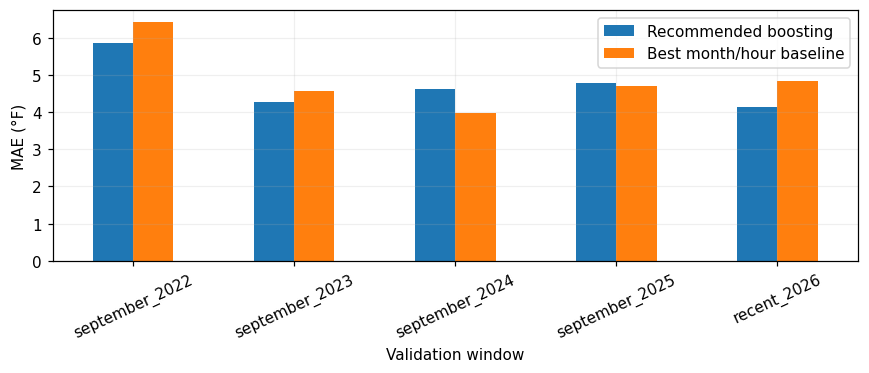

Earlier compact-grid result (leaf size 50 / L2=1):
Recommended settings match src defaults and the shared experiment.
Parameters: {'loss': 'squared_error', 'learning_rate': 0.05, 'max_iter': 150, 'max_leaf_nodes': 7, 'max_depth': None, 'min_samples_leaf': 100, 'l2_regularization': 1.0, 'early_stopping': False, 'random_state': 520}
Features: ['hour', 'month', 'dayofyear', 'hour_sin', 'hour_cos', 'year_sin', 'year_cos']
Main workflow validation fits: 120
Windows improved: 3 / 5


In [12]:
previous_development, _ = run_or_load('development', results['stages']['development']['experiment'])
print('Earlier compact-grid result (leaf size 50 / L2=1):')
display(previous_development[['candidate', 'lookback', 'mean_mae']].head(3).round(6))
development, development_run = run_or_load('development_regularized', load_experiment(PROJECT_ROOT / 'configs/gradient_boosting.json'))
for key in ['max_iter', 'max_leaf_nodes']:
    development[key] = development.candidate_id.map(lambda name: development_run['candidates'][name]['params'].get(key))
display(development[['candidate', 'max_iter', 'max_leaf_nodes', 'lookback', 'mean_mae']].round(3))
best = development.iloc[0]
chosen = development_run['candidates'][best.candidate_id]
default_params, default_columns = resolve_config()
assert chosen['params'] == default_params and chosen['feature_columns'] == default_columns
assert best.lookback == 'all'
main_candidates, main_lookbacks = expand_candidates(load_experiment(PROJECT_ROOT / 'configs/experiment.json'))
assert any(c['model'] == 'gradient_boosting' and c['params'] == default_params and
           c['feature_columns'] == default_columns for c in main_candidates.values())
print('Recommended settings match src defaults and the shared experiment.')
print('Parameters:', default_params)
print('Features:', default_columns)
print('Main workflow validation fits:', len(main_candidates) * len(main_lookbacks) * len(VALIDATION_WINDOWS))

chosen_metrics = pd.DataFrame(development_run['metrics'])
chosen_metrics = chosen_metrics.loc[(chosen_metrics.candidate_id == best.candidate_id) & (chosen_metrics.lookback == 'all')]
baseline = history.loc[history.model == 'month_hour'].iloc[0]
baseline_metrics = pd.DataFrame(history_run['metrics'])
baseline_metrics = baseline_metrics.loc[(baseline_metrics.candidate_id == baseline.candidate_id) &
                                        (baseline_metrics.lookback == baseline.lookback)]
window_mae = pd.DataFrame({'Recommended boosting': chosen_metrics.set_index('window').mae,
                           'Best month/hour baseline': baseline_metrics.set_index('window').mae})
display(window_mae.round(3))
window_mae.plot.bar(figsize=(8, 3.5), rot=25)
plt.ylabel('MAE (°F)'); plt.xlabel('Validation window'); plt.tight_layout(); plt.show()
print('Windows improved:', int((window_mae.iloc[:, 0] < window_mae.iloc[:, 1]).sum()), '/ 5')

## 10. Suggested decisions and application to src

| Decision | Evidence and implementation |
|---|---|
| Use combined calendar inputs as the default | Best tested 14-day mean MAE, **4.733°F**, versus **4.897°F** for the best month/hour baseline. `src/gradient_boosting_model.py` resolves the seven shared features from `src/features.py`. |
| Use learning rate 0.05, 150 iterations, 7 leaves, minimum leaf size 100, L2 1 | Leaf size 100 wins the bounded follow-up by less than 0.001°F; treat 20/50/100 with L2=1 as practically tied. Keep squared-error loss, seed 520, and `early_stopping=False`. The shared workflow uses the updated adapter defaults. |
| Carry all history forward, while retaining lookback comparisons | All history wins for the boosting finalists. `src/backtesting.py` selects each pre-origin history; the shared config still compares all/five/three years during model selection. |
| Retain recursive and direct/weather options, leave them out of the main shortlist | Recursive inputs help day one but worsen full-horizon MAE. Tuned weather is close but does not improve the selected mean MAE. `src/gradient_boosting_features.py` and the adapter preserve explicit feature-set experiments. |
| Retain optional weather preparation | `include_weather=True` / `--include-weather` supplies only historical weather. The default temperature-only pipeline and legacy split columns remain compatible with the other models. |
| Use the shared adapter for every stage | `src/models.py` registers the adapter; `src/workflow.py` tunes, selects, audits a locked selection, and refits the final forecast. No separate tuning framework or notebook-only model implementation is required. |

The selected model improves on the best month/hour baseline in **3/5 windows**, not
every window. Its advantage over tuned wind context is only about **0.016°F**.
Repeated use of these five windows makes all of these **development scores**, not
independent final performance estimates. We tested minimum leaf size and L2 in a
bounded follow-up; we did not tune loss, maximum depth, or every feature/parameter
combination. Stop expanding boosting for this PR; run the
shared model comparison with linear regression and Prophet before locking the
project selection. The historical audit has been inspected earlier in the project;
acknowledge that when reporting it. Submission actual temperatures are never inputs.

For a programmatic development rerun:
`python -m src.workflow --config configs/gradient_boosting.json --validation-only`.
For the bounded regularization search:
`python -m src.workflow --config configs/gradient_boosting_regularization.json --validation-only`.
For the complete team comparison, locked audit, and final 336-hour forecast:
`python -m src.workflow`.